# ABC Tech ITSM: Machine Learning for IT Service Management

**Project:** PM-PR-0012 (client: ABC Tech) | **Author:** Shravani | **Data:** 46,606 incident records (2012-2014) from the MySQL table `project_itsm.dataset_list`

ABC Tech receives roughly 22-25k tickets a quarter and runs mature ITIL processes, yet a recent customer survey rates incident management as poor. This notebook tests the four ways machine learning could help that the project brief lists, and reports honestly what the data can and cannot support.

**Contents:** 2. Data and preparation | 3. Predicting high-priority tickets | 4. Forecasting incident volume | 5. Auto-tagging priority and department | 6. Change (RFC) and asset risk | 7. Recommendations | 8. Limitations

## 1. Summary of results

| Brief item | Headline result | Key insight |
|---|---|---|
| **1. Predict priority 1 and 2 tickets** | Logistic regression with a threshold chosen by cross-validation: precision 0.54, recall 0.67, F1 0.60 on a 1.5% positive class | At the default threshold precision was only 0.20; threshold tuning made the model usable as a triage aid |
| **2. Forecast incident volume (by field, quarterly, annual)** | A naive "same weekday last week" baseline (MAE 27.0) beat Random Forest (31.4) and Gradient Boosting (51.3). Projection: about 21,200 tickets in Q2-2014 | Weekly seasonality dominates. Only two full quarters exist, so quarterly and annual figures are projections, not validated forecasts |
| **3a. Auto-tag priority** | Priority equals urgency for 99.0% of tickets. The 1,380 tickets with no priority all lack only `Impact` and can be tagged by this rule. A model using ticket attributes alone reaches only macro F1 0.51 | The gap is a data-entry problem, not a modeling problem |
| **3b. Auto-tag department (assignment group)** | Macro F1 0.413 across 31 classes using clean features | Groups with identical CI signatures cannot be told apart. Tickets with 4+ reassignments are 9% of tickets but about 39% of elapsed resolution time |
| **4. Predict RFC and asset failure** | 219 changes classified into four risk tiers with a 5-change watchlist, an asset (CI) risk ranking, and a burst-based alert rule. Change-linked incidents are about 3.8 times more likely to be P1/P2 | The database has no change-outcome field, so this is a proxy analysis, not a failure model |

**Approach throughout:** in each sub-task I checked what the data could support before choosing a method. Where a simple baseline was the honest best result (forecasting), where a rule beat a model (priority), or where the data could not support the requested model (RFC failure), that is reported as a finding.

**Note on time measures:** every "handle time" or "resolution time" in this notebook means *elapsed resolution time* (resolved minus opened), not the original `Handle_Time_hrs` field. See section 2.

## 2. Data and preparation

**Source.** 46,606 incident rows and 25 columns from a read-only MySQL database. `dataset_list` is the only table, so there is no separate change or configuration table. Credentials are read from a `.env` file that is excluded from version control.

**Priority matrix.** `Priority` follows the Impact x Urgency matrix in the brief (checked below). `number_cnt` exists in the database but not in the brief's field list and holds random-looking decimals, so it is excluded from all models.

In [1]:
import os
import pandas as pd
import numpy as np
from urllib.parse import quote_plus
from sqlalchemy import create_engine
from dotenv import load_dotenv

load_dotenv(r"C:\Users\Prakash\Desktop\itsm_project\.env")


DB_HOST = os.environ["ITSM_DB_HOST"]
DB_USER = os.environ["ITSM_DB_USER"]
DB_PASS = quote_plus(os.environ["ITSM_DB_PASS"])
DB_NAME = os.environ["ITSM_DB_NAME"]


engine = create_engine(
    f"mysql+mysqlconnector://{DB_USER}:{DB_PASS}@{DB_HOST}/{DB_NAME}"
)

tables = pd.read_sql("SHOW TABLES;", engine)
print(tables)

  Tables_in_project_itsm
0           dataset_list


In [2]:
df_raw = pd.read_sql("SELECT * FROM dataset_list", engine)
df_raw.to_csv("abc_tech_incidents_raw.csv", index=False)
print(df_raw.shape)
df_raw.head()

(46606, 25)


,CI_Name,CI_Cat,CI_Subcat,WBS,Incident_ID,Status,Impact,Urgency,Priority,number_cnt,...,Reopen_Time,Resolved_Time,Close_Time,Handle_Time_hrs,Closure_Code,No_of_Related_Interactions,Related_Interaction,No_of_Related_Incidents,No_of_Related_Changes,Related_Change
0,SUB000508,subapplication,Web Based Application,WBS000162,IM0000004,Closed,4,4,4,0.601292279,...,,04-11-2013 13:50,04-11-2013 13:51,"3,87,16,91,111",Other,1,SD0000007,2,,
1,WBA000124,application,Web Based Application,WBS000088,IM0000005,Closed,3,3,3,0.415049969,...,02-12-2013 12:31,02-12-2013 12:36,02-12-2013 12:36,"4,35,47,86,389",Software,1,SD0000011,1,,
2,DTA000024,application,Desktop Application,WBS000092,IM0000006,Closed,NS,3,NA,0.517551335,...,,13-01-2014 15:12,13-01-2014 15:13,"4,84,31,19,444",No error - works as designed,1,SD0000017,,,
3,WBA000124,application,Web Based Application,WBS000088,IM0000011,Closed,4,4,4,0.642927218,...,,14-11-2013 09:31,14-11-2013 09:31,"4,32,18,33,333",Operator error,1,SD0000025,,,
4,WBA000124,application,Web Based Application,WBS000088,IM0000012,Closed,4,4,4,0.345258343,...,,08-11-2013 13:55,08-11-2013 13:55,"3,38,39,03,333",Other,1,SD0000029,,,


In [3]:
df = df_raw.replace(r'^\s*$', np.nan, regex=True)

In [4]:
time_cols = ["Open_Time", "Reopen_Time", "Resolved_Time", "Close_Time"]
for col in time_cols:
    df[col] = pd.to_datetime(df[col], format="%d-%m-%Y %H:%M", errors="coerce")

df[time_cols].head(10)

,Open_Time,Reopen_Time,Resolved_Time,Close_Time
0,2012-02-05 13:32:00,NaT,2013-11-04 13:50:00,2013-11-04 13:51:00
1,2012-03-12 15:44:00,2013-12-02 12:31:00,2013-12-02 12:36:00,2013-12-02 12:36:00
2,2012-03-29 12:36:00,NaT,2014-01-13 15:12:00,2014-01-13 15:13:00
3,2012-07-17 11:49:00,NaT,2013-11-14 09:31:00,2013-11-14 09:31:00
4,2012-08-10 11:01:00,NaT,2013-11-08 13:55:00,2013-11-08 13:55:00
5,2012-08-10 11:27:00,NaT,2013-11-08 13:54:00,2013-11-08 13:54:00
6,2012-08-15 14:17:00,NaT,2013-12-27 10:59:00,2013-12-27 10:59:00
7,2012-08-22 16:31:00,NaT,2013-11-08 14:09:00,2013-11-08 14:09:00
8,2012-08-29 15:59:00,NaT,2013-11-08 14:02:00,2013-11-08 14:02:00
9,2012-09-03 16:04:00,NaT,2013-11-08 14:33:00,2013-11-08 14:35:00


In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct}).sort_values("missing_pct", ascending=False)

,missing_count,missing_pct
Related_Change,46046,98.80
No_of_Related_Changes,46046,98.80
No_of_Related_Incidents,45384,97.38
Reopen_Time,44322,95.10
Resolved_Time,1780,3.82
Closure_Code,460,0.99
No_of_Related_Interactions,114,0.24
CI_Subcat,111,0.24
CI_Cat,111,0.24
Priority,0,0.00


**Missing-value findings.** A plain `isnull()` first reported no missing values because blank strings (`''`) were hiding them; replacing blanks with `NaN` exposed the real picture. `Related_Change` and `No_of_Related_Changes` are 98.8% missing, `No_of_Related_Incidents` 97.4%, `Reopen_Time` 95.1%, `Resolved_Time` 3.8%, `Closure_Code` about 1% and `CI_Cat` / `CI_Subcat` 0.24%. Dates are day-first (`dd-mm-yyyy`), which the brief's sample ticket confirms.

In [6]:
computed_hours = (df["Resolved_Time"] - df["Open_Time"]).dt.total_seconds() / 3600

comparison = pd.DataFrame({
    "raw_Handle_Time_hrs": df["Handle_Time_hrs"],
    "computed_from_timestamps": computed_hours
})
comparison.describe()

,computed_from_timestamps
count,44826.000000
mean,124.651404
std,453.273762
min,0.000000
25%,1.283333
50%,18.758333
75%,95.829167
max,15722.600000


In [7]:
comparison.sample(20, random_state=1)

,raw_Handle_Time_hrs,computed_from_timestamps
37603,"7,98,17,22,222",312.033333
11776,"0,458055556",0.450000
21168,"0,033055556",97.616667
1907,"4,75,83,33,333",18.266667
37578,"0,248888889",166.933333
16375,"0,541388889",0.550000
17643,"1,99,06,94,444",1446.450000
28420,"3,12,86,11,111",16.616667
4436,"0,597222222",0.600000
37431,"2,20,02,77,778",49.000000


**Note on `Handle_Time_hrs`.** The original column is stored as locale-formatted text (for example `3,87,16,91,111`) and does not parse reliably. The brief's own sample ticket lists 3,871.69 hours, while resolved minus opened for that ticket is about 15,312 hours, so the original field is a different measure from elapsed time. The next cells therefore replace it with **elapsed resolution time** (`Resolved_Time - Open_Time`, or `Close_Time - Open_Time` for the 1,780 tickets, 3.8%, with no `Resolved_Time`). The column name is kept, but every time figure in this notebook means elapsed resolution time.

In [8]:
df["Handle_Time_hrs"] = computed_hours
df = df.drop(columns=["raw_Handle_Time_hrs"], errors="ignore")  # in case you added it separately
df["Handle_Time_hrs"].describe()


count    44826.000000
mean       124.651404
std        453.273762
min          0.000000
25%          1.283333
50%         18.758333
75%         95.829167
max      15722.600000
Name: Handle_Time_hrs, dtype: float64

In [9]:
print(df["Handle_Time_hrs"].isnull().sum())

1780


In [10]:
missing_handle_time = df[df["Handle_Time_hrs"].isnull()]
missing_handle_time["Status"].value_counts()

Status
Closed    1780
Name: count, dtype: int64

In [11]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct}).sort_values("missing_pct", ascending=False)

,missing_count,missing_pct
Related_Change,46046,98.80
No_of_Related_Changes,46046,98.80
No_of_Related_Incidents,45384,97.38
Reopen_Time,44322,95.10
Handle_Time_hrs,1780,3.82
Resolved_Time,1780,3.82
Closure_Code,460,0.99
CI_Subcat,111,0.24
CI_Cat,111,0.24
No_of_Related_Interactions,114,0.24


In [12]:
missing_idx = df[df["Handle_Time_hrs"].isnull()].index
df_raw.loc[missing_idx, ["Status", "Open_Time", "Resolved_Time", "Close_Time"]].head(20)

,Status,Open_Time,Resolved_Time,Close_Time
13,Closed,15-10-2012 15:50,,14-11-2013 13:33
29,Closed,18-02-2013 11:59,,04-12-2013 14:00
36,Closed,01-03-2013 10:19,,27-01-2014 12:44
71,Closed,07-05-2013 15:04,,09-12-2013 08:42
76,Closed,22-05-2013 00:42,,17-01-2014 15:00
78,Closed,22-05-2013 11:21,,14-10-2013 14:15
114,Closed,19-06-2013 15:33,,10-10-2013 17:26
154,Closed,12-07-2013 15:11,,27-11-2013 15:36
171,Closed,17-07-2013 10:13,,01-10-2013 15:19
184,Closed,25-07-2013 11:52,,01-10-2013 16:41


In [13]:
df["Handle_Time_hrs"] = np.where(
    df["Resolved_Time"].isnull(),
    (df["Close_Time"] - df["Open_Time"]).dt.total_seconds() / 3600,
    df["Handle_Time_hrs"]
)

print(df["Handle_Time_hrs"].isnull().sum())
df["Handle_Time_hrs"].describe()

0


count    46606.000000
mean       123.126505
std        452.794257
min          0.000000
25%          1.266667
50%         18.400000
75%         95.050000
max      15722.600000
Name: Handle_Time_hrs, dtype: float64

In [14]:
df["Resolved_Time_missing"] = df["Resolved_Time"].isnull().astype(int)

In [15]:
df["Related_Change"] = df["Related_Change"].fillna("None")
df["No_of_Related_Changes"] = df["No_of_Related_Changes"].fillna(0)
df["No_of_Related_Incidents"] = df["No_of_Related_Incidents"].fillna(0)
df["Reopen_Time_missing"] = df["Reopen_Time"].isnull().astype(int)

df["Closure_Code"] = df["Closure_Code"].fillna("Unknown")
df["CI_Cat"] = df["CI_Cat"].fillna("Unknown")
df["CI_Subcat"] = df["CI_Subcat"].fillna("Unknown")
df["No_of_Related_Interactions"] = df["No_of_Related_Interactions"].fillna(0)
df["No_of_Reassignments"] = df["No_of_Reassignments"].fillna(0)

df.isnull().sum().sort_values(ascending=False)

Reopen_Time                   44322
Resolved_Time                  1780
CI_Name                           0
WBS                               0
Incident_ID                       0
Status                            0
Impact                            0
Urgency                           0
Priority                          0
CI_Cat                            0
CI_Subcat                         0
Category                          0
number_cnt                        0
KB_number                         0
Alert_Status                      0
Open_Time                         0
No_of_Reassignments               0
Close_Time                        0
Handle_Time_hrs                   0
Closure_Code                      0
No_of_Related_Interactions        0
Related_Interaction               0
No_of_Related_Incidents           0
No_of_Related_Changes             0
Related_Change                    0
Resolved_Time_missing             0
Reopen_Time_missing               0
dtype: int64

In [16]:
df.to_csv("abc_tech_incidents_cleaned.csv", index=False)
print(df.shape)
df.dtypes

(46606, 27)


CI_Name                               object
CI_Cat                                object
CI_Subcat                             object
WBS                                   object
Incident_ID                           object
Status                                object
Impact                                object
Urgency                               object
Priority                              object
number_cnt                            object
Category                              object
KB_number                             object
Alert_Status                          object
No_of_Reassignments                   object
Open_Time                     datetime64[ns]
Reopen_Time                   datetime64[ns]
Resolved_Time                 datetime64[ns]
Close_Time                    datetime64[ns]
Handle_Time_hrs                      float64
Closure_Code                          object
No_of_Related_Interactions            object
Related_Interaction                   object
No_of_Rela

In [17]:
df["Priority"].value_counts()

Priority
4     22717
5     16486
3      5323
NA     1380
2       697
1         3
Name: count, dtype: int64

In [18]:
df["Priority"] = df["Priority"].replace("NA", np.nan)
print(df["Priority"].isnull().sum())

1380


**Missing priority.** 1,380 tickets have `Priority = "NA"`. Section 5.1 shows they all have `Impact = "NS"` (not specified). They are removed from model training here and tagged separately by rule later. That leaves **45,226** tickets. The target `is_high_priority` is 1 for priority 1 or 2.

In [19]:
df = df[df["Priority"].notnull()]
print(df.shape)

(45226, 27)


In [20]:
df["Priority"] = df["Priority"].astype(int)
df["is_high_priority"] = df["Priority"].isin([1, 2]).astype(int)
df["is_high_priority"].value_counts()


is_high_priority
0    44526
1      700
Name: count, dtype: int64

In [21]:
df.to_csv("abc_tech_incidents_cleaned.csv", index=False)

In [22]:
pd.crosstab(df["Impact"], df["Urgency"]).head(20)
df.groupby(["Impact", "Urgency"])["Priority"].value_counts().head(20)

Impact  Urgency       Priority
1       1             1               3
2       2             2             689
        3             2               3
3       1             2               2
        2             2               3
        3             3            5077
        4             3             144
        5             4               8
4       2             3               3
        3             3              97
        4             4           22170
        5             4             286
5       1             3               1
        2             3               1
        3             4              11
        4             4             242
        5             5           16485
        5 - Very Low  5               1
Name: count, dtype: int64

**Impact x Urgency check.** Every Impact/Urgency pair above agrees with the priority matrix in the brief (for example impact 4 with urgency 4 gives priority 4, impact 5 with urgency 5 gives priority 5). `Impact` equals `Urgency` for about 98% of tickets. `"5 - Very Low"` is merged into `"5"` in the next cell (only one ticket).

In [23]:
df["Urgency"] = df["Urgency"].replace("5 - Very Low", "5")

## 3. Sub-task 1: Predicting high-priority incidents

**Goal (brief item 1):** flag priority 1 and 2 tickets early so preventive action is possible.

**Target:** `is_high_priority`. There are 700 positives in 45,226 tickets (1.55%): 697 are P2 and only 3 are P1, so this is effectively a P2 model.

**Features (known at ticket creation):** `CI_Cat`, `CI_Subcat`, `Category`, and the hour, day of week and month of `Open_Time`. `Impact` and `Urgency` are **not** used because they determine priority directly. `Alert_Status` has a single value and is dropped.

**Split:** stratified 80/20 (36,180 train / 9,046 test) with the positive rate preserved at about 1.55%.

In [24]:
feature_cols = ["CI_Cat", "CI_Subcat", "Category", "Alert_Status"]
df["open_hour"] = df["Open_Time"].dt.hour
df["open_dayofweek"] = df["Open_Time"].dt.dayofweek
df["open_month"] = df["Open_Time"].dt.month

feature_cols += ["open_hour", "open_dayofweek", "open_month"]
X = df[feature_cols]
y = df["is_high_priority"]
print(X.shape, y.shape)
X.head()

(45226, 7) (45226,)


,CI_Cat,CI_Subcat,Category,Alert_Status,open_hour,open_dayofweek,open_month
0,subapplication,Web Based Application,incident,closed,13,6,2
1,application,Web Based Application,incident,closed,15,0,3
3,application,Web Based Application,incident,closed,11,1,7
4,application,Web Based Application,incident,closed,11,4,8
5,application,Web Based Application,incident,closed,11,4,8


In [25]:
for col in ["CI_Cat", "CI_Subcat", "Category", "Alert_Status"]:
    print(col, X[col].nunique())

CI_Cat 13
CI_Subcat 63
Category 4
Alert_Status 1


In [26]:
feature_cols = ["CI_Cat", "CI_Subcat", "Category", "open_hour", "open_dayofweek", "open_month"]
X = df[feature_cols]

In [27]:
from sklearn.model_selection import train_test_split

X_encoded = pd.get_dummies(X, columns=["CI_Cat", "CI_Subcat", "Category"], drop_first=True)
y = df["is_high_priority"]

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))


(36180, 80) (9046, 80)
is_high_priority
0    0.984522
1    0.015478
Name: proportion, dtype: float64
is_high_priority
0    0.984524
1    0.015476
Name: proportion, dtype: float64


In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report , confusion_matrix,
    precision_recall_curve, average_precision_score, f1_score
)
import matplotlib.pyplot as plt

log_reg = LogisticRegression(
    class_weight = "balanced",
    max_iter=1000,
    random_state=42
)
log_reg.fit(X_train, y_train)

y_pred=log_reg.predict(X_test)
y_proba=log_reg.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=["Not High Priority", "High Priority"]))
print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred))
print("PR-AUC (Average Precision):", average_precision_score(y_test, y_proba))

                   precision    recall  f1-score   support

Not High Priority       1.00      0.95      0.97      8906
    High Priority       0.20      0.74      0.31       140

         accuracy                           0.95      9046
        macro avg       0.60      0.84      0.64      9046
     weighted avg       0.98      0.95      0.96      9046

Confusion Matrix:
 [[8482  424]
 [  37  103]]
PR-AUC (Average Precision): 0.43074444199016826


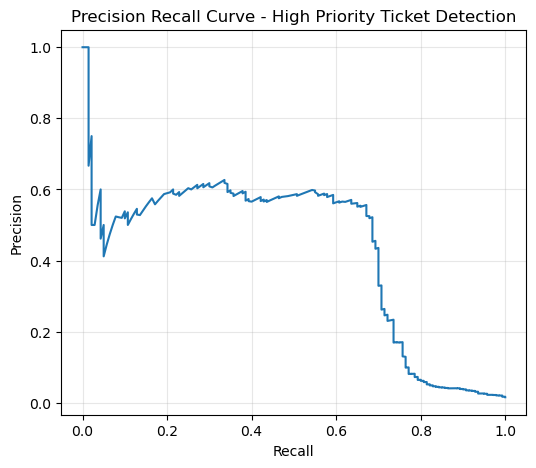

In [29]:
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(6,5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision Recall Curve - High Priority Ticket Detection")
plt.grid(True, alpha = 0.3)
plt.show()

In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, average_precision_score

rf = RandomForestClassifier (
    n_estimators=300,
    class_weight="balanced",
    random_state = 42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf, target_names=["Not High Priority", "High Priority"]))
print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred_rf))
print("PR-AUC (Average Precision):", average_precision_score(y_test, y_proba_rf))

                   precision    recall  f1-score   support

Not High Priority       0.99      0.96      0.98      8906
    High Priority       0.19      0.60      0.29       140

         accuracy                           0.95      9046
        macro avg       0.59      0.78      0.63      9046
     weighted avg       0.98      0.95      0.97      9046

Confusion Matrix:
 [[8546  360]
 [  56   84]]
PR-AUC (Average Precision): 0.3668435373988859


**Results at the default threshold (0.5).**

| Model | Precision (P1/P2) | Recall (P1/P2) | PR-AUC |
|---|---|---|---|
| Logistic regression, balanced class weights | 0.20 | 0.74 | 0.431 |
| Random Forest (300 trees, balanced) | 0.19 | 0.60 | 0.367 |

Accuracy of about 95% is misleading with 1.5% positives, so precision, recall and PR-AUC are the metrics to read. Logistic regression is the stronger model, but at 0.5 it raises many false alarms.

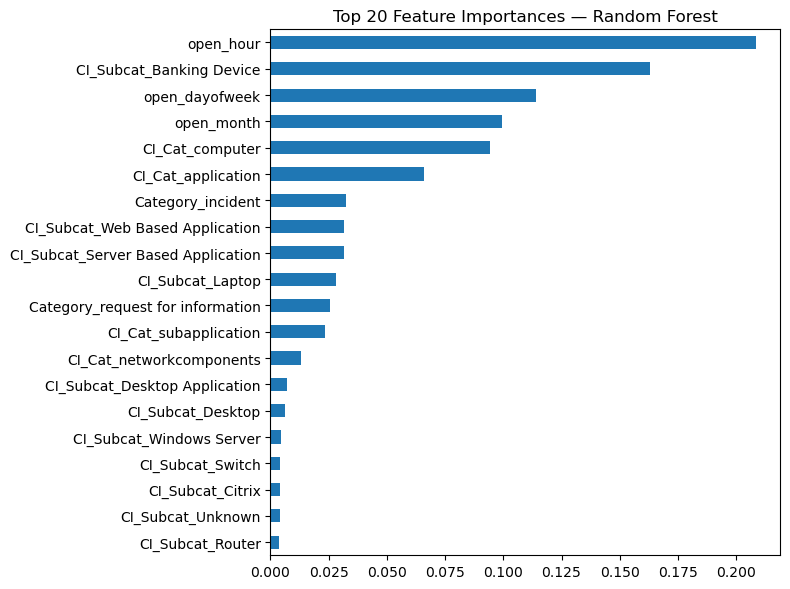

In [31]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False).head(20).plot(kind="barh", figsize=(8, 6))
plt.title("Top 20 Feature Importances — Random Forest")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

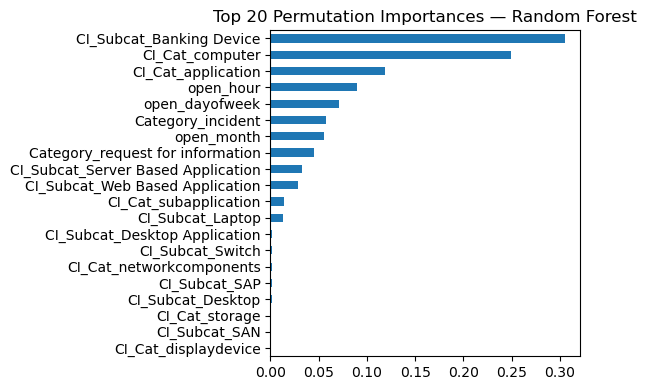

In [32]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    rf, X_test, y_test,
    n_repeats=10, random_state=42, scoring="average_precision", n_jobs=-1
)

perm_importances = pd.Series(perm_result.importances_mean, index=X_test.columns)
perm_importances.sort_values(ascending=False).head(20).plot(kind="barh", figsize=(6, 4))
plt.title("Top 20 Permutation Importances — Random Forest")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Feature importance.** Impurity-based importances favour `open_hour` and `open_dayofweek`, a known bias toward features with many distinct values. Permutation importance is more trustworthy: `CI_Subcat_Banking Device`, `CI_Cat_computer` and `CI_Cat_application` are the strongest real drivers.

**Exploratory: threshold tuned on the test set.** This cell picks the threshold directly on the test data (0.971: precision 0.56, recall 0.60). That is optimistic because the test set influenced the choice, so it is shown only for comparison. The next cell does it properly.

In [33]:
import numpy as np

precision_lr, recall_lr, thresholds_lr = precision_recall_curve(y_test, y_proba)

target_recall = 0.6
idx = np.argmin(np.abs(recall_lr[:-1] - target_recall))
print(f"Threshold: {thresholds_lr[idx]:.3f}, Precision: {precision_lr[idx]:.3f}, Recall: {recall_lr[idx]:.3f}")

y_pred_thresh = (y_proba >= thresholds_lr[idx]).astype(int)
print(classification_report(y_test, y_pred_thresh, target_names=["Not High Priority", "High Priority"]))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_thresh))

Threshold: 0.971, Precision: 0.564, Recall: 0.600
                   precision    recall  f1-score   support

Not High Priority       0.99      0.99      0.99      8906
    High Priority       0.56      0.60      0.58       140

         accuracy                           0.99      9046
        macro avg       0.78      0.80      0.79      9046
     weighted avg       0.99      0.99      0.99      9046

Confusion Matrix:
 [[8841   65]
 [  56   84]]


In [34]:

from sklearn.model_selection import cross_val_predict, StratifiedKFold

oof = cross_val_predict(
    log_reg, X_train, y_train,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    method="predict_proba")[:, 1]

prec_cv, rec_cv, thr_cv = precision_recall_curve(y_train, oof)
t_final = thr_cv[np.argmin(np.abs(rec_cv[:-1] - 0.6))]
print("Threshold chosen on training data only:", round(t_final, 3))

test_pred = (log_reg.predict_proba(X_test)[:, 1] >= t_final).astype(int)
print(classification_report(y_test, test_pred, target_names=["Not High Priority", "High Priority"]))
print(confusion_matrix(y_test, test_pred))

Threshold chosen on training data only: 0.92
                   precision    recall  f1-score   support

Not High Priority       0.99      0.99      0.99      8906
    High Priority       0.54      0.67      0.60       140

         accuracy                           0.99      9046
        macro avg       0.77      0.83      0.79      9046
     weighted avg       0.99      0.99      0.99      9046

[[8825   81]
 [  46   94]]


**Final model: threshold chosen by cross-validation on the training data only.** The threshold (about 0.92, targeting roughly 60% recall) is chosen with 5-fold out-of-fold predictions on the training set and then applied once to the test set.

| | Threshold | Precision | Recall | F1 | Confusion matrix |
|---|---|---|---|---|---|
| Tuned on test (exploratory) | 0.971 | 0.56 | 0.60 | 0.58 | [[8841, 65], [56, 84]] |
| **Tuned on training data (final)** | **0.92** | **0.54** | **0.67** | **0.60** | **[[8825, 81], [46, 94]]** |

The two results are nearly identical, so the earlier figure was not inflated. The model catches 94 of 140 high-priority test tickets (67%) with 81 false alarms, which is a reasonable trade-off for a triage aid. With only 140 positives, treat the figures as roughly plus or minus 4 percentage points. The 1,380 excluded tickets are unlikely to matter: they have urgency 3 or 4, and only 3 of 5,188 labeled urgency-3 tickets were P2.

## 4. Sub-task 2: Forecasting incident volume

**Goal (brief item 2):** forecast volume by field, quarterly and annually, to plan resources.

**Setup.** Tickets are aggregated to daily counts by `Open_Time`. Only 327 of 786 calendar days have any tickets, and volume is consistent only from about **24 Sept 2013**. Many of the earliest tickets were resolved in bulk in late 2013 (for example five tickets opened in 2012 all show resolution on 8 Nov 2013), which suggests backlog clean-up or late data entry at go-live. The active period (189 days, missing days filled with 0) is used for modeling.

### 4.1 Daily forecasting

**Pattern.** Strong weekday/weekend seasonality: Monday-Friday averages roughly 270-370 tickets a day, Saturday about 10 and Sunday about 2.

**Features** (all lagged to avoid leakage): `lag_1`, `lag_2`, `lag_7`, `rolling_mean_7`, `rolling_std_7`, `dayofweek_num`, `is_weekend`. **Time-based split:** train 2013-10-01 to 2014-02-22 (145 days), test 2014-02-23 to 2014-03-31 (37 days).

In [35]:
daily_counts =df.groupby(df["Open_Time"].dt.date).size().reset_index()
daily_counts.columns = ["date","incident_count"]
daily_counts["date"]=pd.to_datetime(daily_counts["date"])
daily_counts=daily_counts.sort_values("date").reset_index(drop=True)

print(daily_counts.shape)
daily_counts.head()

(327, 2)


,date,incident_count
0,2012-02-05,1
1,2012-03-12,1
2,2012-07-17,1
3,2012-08-10,2
4,2012-08-15,1


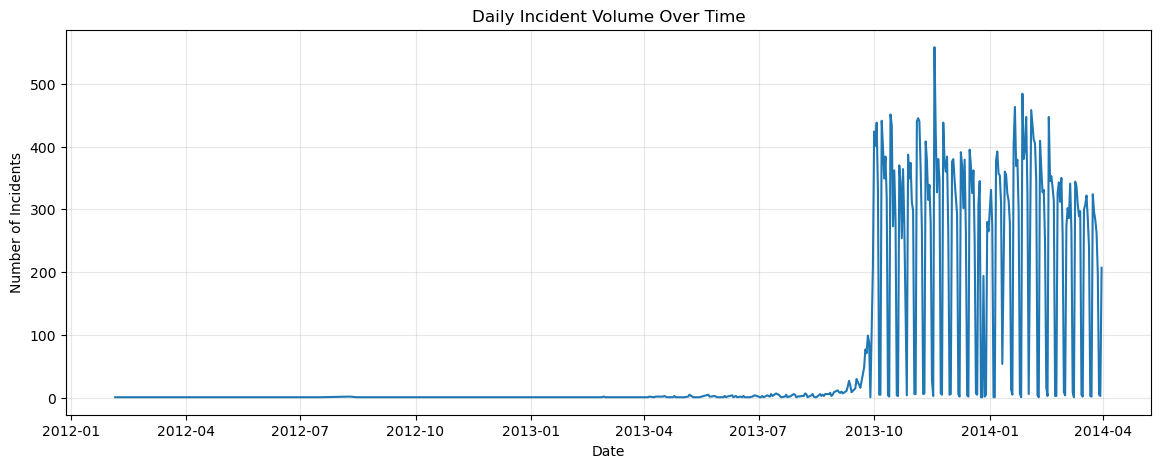

Date range: 2012-02-05 00:00:00 to 2014-03-31 00:00:00
Total days in range: 786, days with data: 327, missing days: 459


count    327.000000
mean     138.305810
std      170.147495
min        1.000000
25%        2.000000
50%        6.000000
75%      321.000000
max      558.000000
Name: incident_count, dtype: float64

In [36]:
plt.figure(figsize=(14, 5))
plt.plot(daily_counts["date"], daily_counts["incident_count"])
plt.title("Daily Incident Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Incidents")
plt.grid(True, alpha=0.3)
plt.show()

full_range = pd.date_range(daily_counts["date"].min(), daily_counts["date"].max())
missing_days = set(full_range) - set(daily_counts["date"])
print(f"Date range: {daily_counts['date'].min()} to {daily_counts['date'].max()}")
print(f"Total days in range: {len(full_range)}, days with data: {len(daily_counts)}, missing days: {len(missing_days)}")
daily_counts["incident_count"].describe()

In [37]:
active_start = daily_counts[daily_counts["incident_count"] > 50]["date"].min()
print("Active period starts around:", active_start)

active_df = daily_counts[daily_counts["date"] >= active_start].copy()
print(active_df.shape)
active_df["incident_count"].describe()

Active period starts around: 2013-09-24 00:00:00
(184, 2)


count    184.000000
mean     242.701087
std      162.739131
min        1.000000
25%        8.500000
50%      307.500000
75%      365.000000
max      558.000000
Name: incident_count, dtype: float64

In [38]:
full_range = pd.date_range(active_df["date"].min(), active_df["date"].max())
active_df = active_df.set_index("date").reindex(full_range).rename_axis("date").reset_index()
active_df["incident_count"] = active_df["incident_count"].fillna(0).astype(int)

print(active_df.shape)
active_df["incident_count"].describe()

(189, 2)


count    189.000000
mean     236.280423
std      165.241669
min        0.000000
25%        7.000000
50%      302.000000
75%      364.000000
max      558.000000
Name: incident_count, dtype: float64

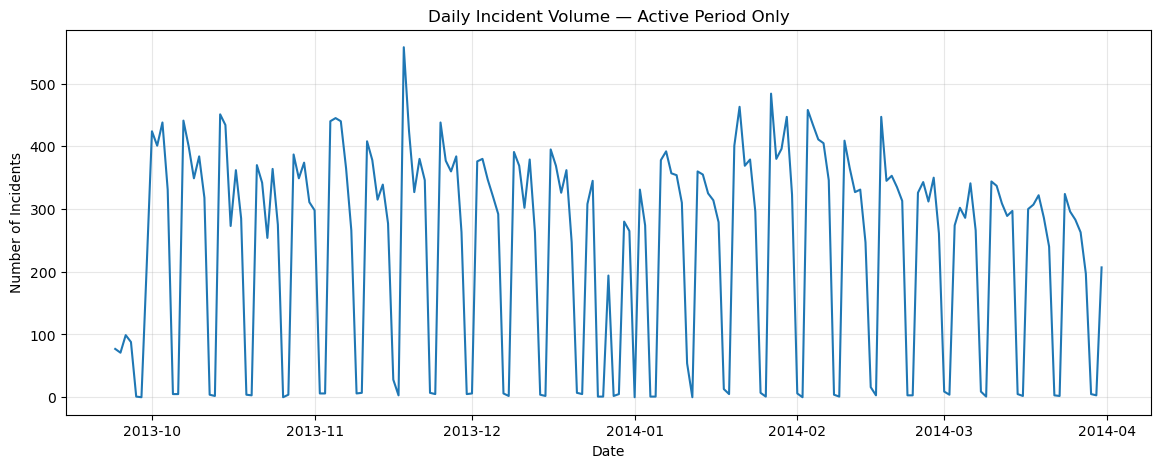

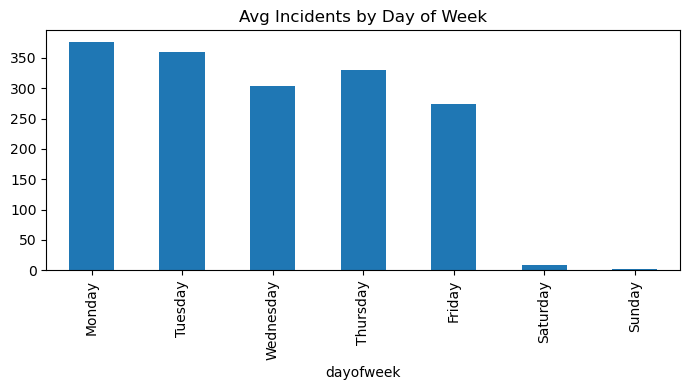

In [39]:
plt.figure(figsize=(14, 5))
plt.plot(active_df["date"], active_df["incident_count"])
plt.title("Daily Incident Volume - Active Period Only")
plt.xlabel("Date")
plt.ylabel("Number of Incidents")
plt.grid(True, alpha=0.3)
plt.show()

active_df["dayofweek"] = active_df["date"].dt.day_name()
active_df.groupby("dayofweek")["incident_count"].mean().reindex(
    ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
).plot(kind="bar", figsize=(7,4), title="Avg Incidents by Day of Week")
plt.tight_layout()
plt.show()

In [40]:
ts = active_df.copy().sort_values("date").reset_index(drop=True)

ts["dayofweek_num"] = ts["date"].dt.dayofweek  
ts["is_weekend"] = ts["dayofweek_num"].isin([5, 6]).astype(int)

ts["lag_1"] = ts["incident_count"].shift(1)
ts["lag_2"] = ts["incident_count"].shift(2)
ts["lag_7"] = ts["incident_count"].shift(7)  

ts["rolling_mean_7"] = ts["incident_count"].shift(1).rolling(window=7).mean()
ts["rolling_std_7"] = ts["incident_count"].shift(1).rolling(window=7).std()

ts_model = ts.dropna().reset_index(drop=True)
print(ts_model.shape)
ts_model.head()

(182, 10)


,date,incident_count,dayofweek,dayofweek_num,is_weekend,lag_1,lag_2,lag_7,rolling_mean_7,rolling_std_7
0,2013-10-01,424,Tuesday,1,0,209.0,0.0,77.0,77.857143,70.433014
1,2013-10-02,401,Wednesday,2,0,424.0,209.0,71.0,127.428571,148.536031
2,2013-10-03,438,Thursday,3,0,401.0,424.0,99.0,174.571429,177.236995
3,2013-10-04,331,Friday,4,0,438.0,401.0,88.0,223.000000,198.218734
4,2013-10-05,5,Saturday,5,1,331.0,438.0,1.0,257.714286,191.810422


In [41]:
split_idx = int(len(ts_model) * 0.8)
train_ts = ts_model.iloc[:split_idx]
test_ts = ts_model.iloc[split_idx:]

feature_cols = ["dayofweek_num", "is_weekend", "lag_1", "lag_2", "lag_7", "rolling_mean_7", "rolling_std_7"]
X_train_ts = train_ts[feature_cols]
y_train_ts = train_ts["incident_count"]
X_test_ts = test_ts[feature_cols]
y_test_ts = test_ts["incident_count"]

print(f"Train: {train_ts['date'].min()} to {train_ts['date'].max()} ({len(train_ts)} days)")
print(f"Test:  {test_ts['date'].min()} to {test_ts['date'].max()} ({len(test_ts)} days)")

Train: 2013-10-01 00:00:00 to 2014-02-22 00:00:00 (145 days)
Test:  2014-02-23 00:00:00 to 2014-03-31 00:00:00 (37 days)


In [42]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

rf_reg = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
rf_reg.fit(X_train_ts, y_train_ts)

y_pred_ts = rf_reg.predict(X_test_ts)

mae = mean_absolute_error(y_test_ts, y_pred_ts)
rmse = np.sqrt(mean_squared_error(y_test_ts, y_pred_ts))
mape = np.mean(np.abs((y_test_ts - y_pred_ts) / y_test_ts.replace(0, np.nan))) * 100

print(f"MAE:  {mae:.2f} incidents/day")
print(f"RMSE: {rmse:.2f} incidents/day")
print(f"MAPE: {mape:.2f}%")

MAE:  31.38 incidents/day
RMSE: 47.04 incidents/day
MAPE: 26.29%


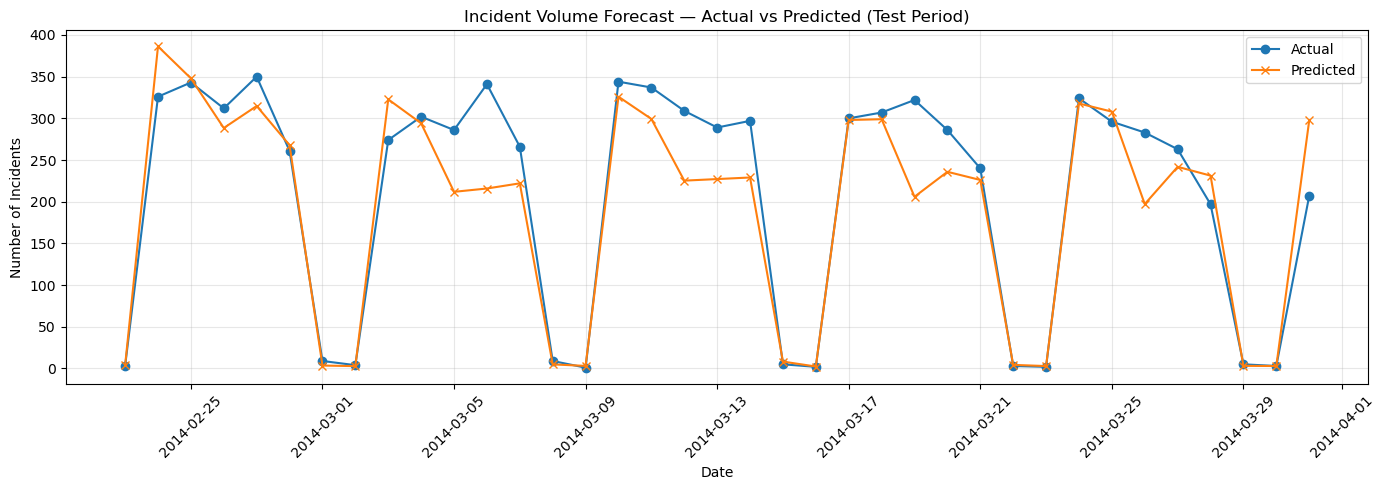

In [43]:
plt.figure(figsize=(14, 5))
plt.plot(test_ts["date"], y_test_ts.values, label="Actual", marker="o")
plt.plot(test_ts["date"], y_pred_ts, label="Predicted", marker="x")
plt.title("Incident Volume Forecast — Actual vs Predicted (Test Period)")
plt.xlabel("Date")
plt.ylabel("Number of Incidents")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [44]:

naive_pred = X_test_ts["lag_7"]
naive_mae = mean_absolute_error(y_test_ts, naive_pred)
print(f"Naive baseline (last week same day) MAE: {naive_mae:.2f}")
print(f"Your model MAE: {mae:.2f}")
print("Model beats naive baseline" if mae < naive_mae else "Model does NOT beat naive baseline")

Naive baseline (last week same day) MAE: 27.00
Your model MAE: 31.38
Model does NOT beat naive baseline


In [45]:
importances_ts = pd.Series(rf_reg.feature_importances_, index=feature_cols)
importances_ts.sort_values(ascending=False)

dayofweek_num     0.368246
is_weekend        0.278216
lag_7             0.252753
lag_1             0.027700
lag_2             0.025869
rolling_mean_7    0.024942
rolling_std_7     0.022274
dtype: float64

In [46]:
from sklearn.ensemble import GradientBoostingRegressor

gb_reg = GradientBoostingRegressor(random_state=42)
gb_reg.fit(X_train_ts, y_train_ts)
y_pred_gb = gb_reg.predict(X_test_ts)

mae_gb = mean_absolute_error(y_test_ts, y_pred_gb)
print(f"Gradient Boosting MAE: {mae_gb:.2f} (naive baseline: {naive_mae:.2f}, RF: {mae:.2f})")

Gradient Boosting MAE: 51.30 (naive baseline: 27.00, RF: 31.38)


**Results.**

| Model | MAE (tickets/day) |
|---|---|
| **Naive baseline: same weekday last week (`lag_7`)** | **27.00** |
| Random Forest | 31.38 (RMSE 47.04, MAPE 26.3%) |
| Gradient Boosting | 51.30 |
| Random Forest + week-over-week trend feature | 37.50 (see next cell for the fair comparison) |

`dayofweek_num`, `is_weekend` and `lag_7` carry about 90% of the Random Forest's importance: it is effectively a noisier copy of the weekly baseline.

In [47]:
ts["lag_7_diff"] = ts["lag_7"] - ts["lag_7"].shift(7)  
ts_model2 = ts.dropna().reset_index(drop=True)

split_idx2 = int(len(ts_model2) * 0.8)
train_ts2 = ts_model2.iloc[:split_idx2]
test_ts2 = ts_model2.iloc[split_idx2:]

feature_cols2 = feature_cols + ["lag_7_diff"]
X_train_ts2 = train_ts2[feature_cols2]
y_train_ts2 = train_ts2["incident_count"]
X_test_ts2 = test_ts2[feature_cols2]
y_test_ts2 = test_ts2["incident_count"]

rf_reg2 = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf_reg2.fit(X_train_ts2, y_train_ts2)
y_pred_ts2 = rf_reg2.predict(X_test_ts2)
mae2 = mean_absolute_error(y_test_ts2, y_pred_ts2)
print(f"MAE with trend feature: {mae2:.2f}")

MAE with trend feature: 37.50


In [48]:

naive2 = mean_absolute_error(y_test_ts2, test_ts2["lag_7"])
print(f"Same test window -> naive: {naive2:.2f} | RF + trend feature: {mae2:.2f}")

Same test window -> naive: 25.09 | RF + trend feature: 37.50


The trend-feature model needs a slightly shorter test window because of the extra lag, so it must be compared with the naive baseline on **that same window**: naive 25.09 against 37.50 for the model. The trend feature made things worse.

**Conclusion.** With 145 training days no model beat "same weekday last week", so the weekly-seasonal naive method is the recommended operational forecast until at least a year of data exists.

### 4.2 Quarterly and annual outlook

The projection multiplies the mean of the last 8 full weeks by 13 (quarter) or 52 (year). The range uses the lowest and highest single weeks, so it is a rough band and not a statistical interval.

In [49]:
act = df[df["Open_Time"] >= "2013-09-24"].copy()
print("Quarterly incident counts")
print(act.groupby(act["Open_Time"].dt.to_period("Q")).size())

weekly = act.set_index("Open_Time").resample("W").size()
recent = weekly.iloc[-9:-1]                     # last 8 full weeks
print("\nQ2-2014 projection:", round(recent.mean() * 13),
      "| range:", round(recent.min() * 13), "to", round(recent.max() * 13))
print("Annualised:", round(recent.mean() * 52))

Quarterly incident counts
Open_Time
2013Q3      545
2013Q4    22796
2014Q1    21316
Freq: Q-DEC, dtype: int64

Q2-2014 projection: 21213 | range: 17823 to 26767
Annualised: 84851


| Quarter | Incidents |
|---|---|
| 2013 Q3 (from 24 Sept only) | 545 |
| 2013 Q4 | 22,796 |
| 2014 Q1 | 21,316 |
| **2014 Q2 (projection)** | **about 21,200** (rough range 17,800 to 26,800) |

Annualised the method gives about 84,900 tickets (rough range 71,000 to 107,000), close to twice the two full quarters (88,200). Observed quarterly volume is consistent with the brief's "22-25k tickets on average", which appears to be a quarterly figure.

**Limits.** Only two full quarters exist, so these projections cannot be back-tested and yearly seasonality cannot be learned (a dip in the week around Christmas is visible, but there is one December only). They assume weekly volume stays near its recent level.

### 4.3 Volume by field

Quarterly counts and Q2-2014 projections (same method) by field. The first and last points of each weekly chart are partial weeks and are dropped from the plots.


=== CI_Cat ===
quarter            2013Q3  2013Q4  2014Q1  Q2_2014_proj
CI_Cat                                                 
application           421   16182   14810       14714.0
subapplication         59    3756    3834        3848.0
computer               51    1942    1522        1536.0
storage                 1     301     350         367.0
software                2     131     160         146.0
hardware                3     120     283         236.0
displaydevice           2     117      92         107.0
officeelectronics       2      82      55          50.0


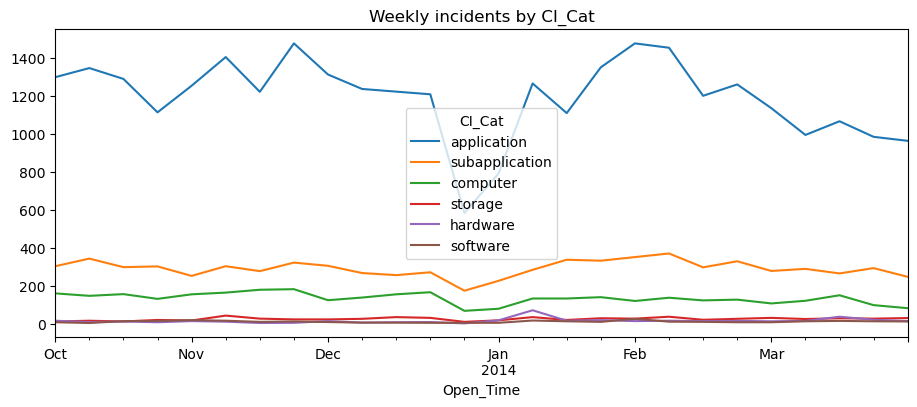


=== Category ===
quarter                  2013Q3  2013Q4  2014Q1  Q2_2014_proj
Category                                                     
incident                    422   17917   17625       17761.0
request for information     122    4873    3686        3447.0
complaint                     1       5       5           5.0
request for change            0       1       0           0.0


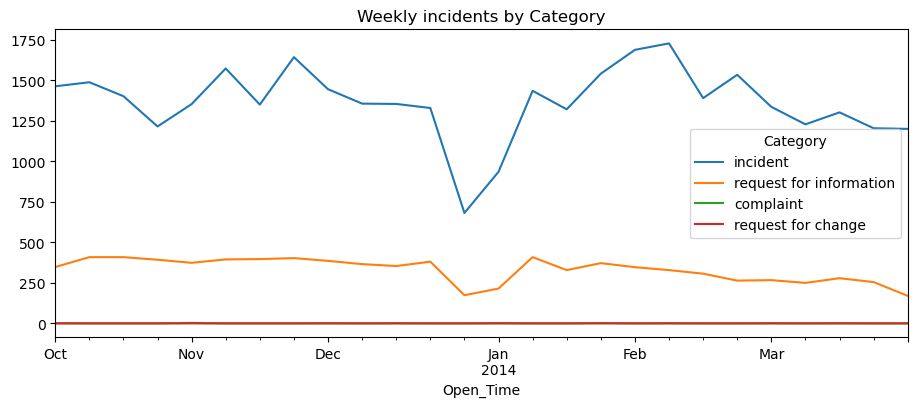


=== WBS ===
quarter    2013Q3  2013Q4  2014Q1  Q2_2014_proj
WBS                                            
WBS000073     125    5992    7084        7168.0
WBS000072      35    1294     827         700.0
WBS000263      23    1141    1097        1019.0
WBS000091      31    1129    1262        1350.0
WBS000271      30     697     409         457.0
WBS000318       8     592     454         486.0
WBS000152      17     585     468         489.0
WBS000095       2     552     543         554.0


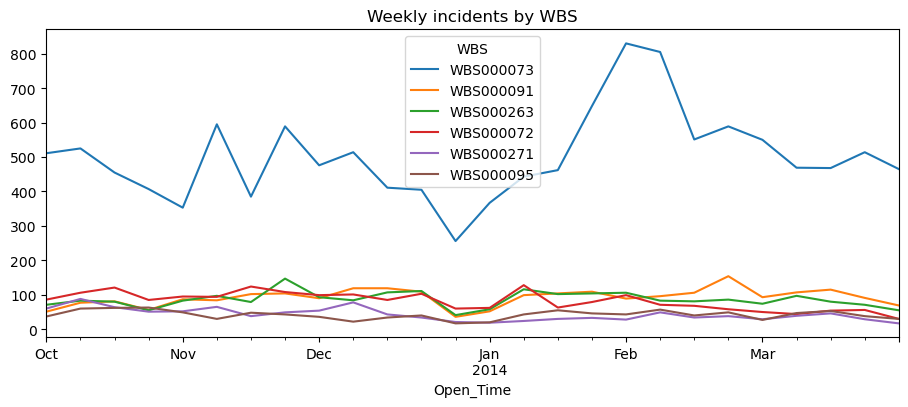

In [51]:
act["quarter"] = act["Open_Time"].dt.to_period("Q").astype(str)

for col in ["CI_Cat", "Category", "WBS"]:
    q = act.groupby([col, "quarter"]).size().unstack(fill_value=0)
    w = (act.groupby([pd.Grouper(key="Open_Time", freq="W"), col])
            .size().unstack(fill_value=0))
    q["Q2_2014_proj"] = (w.iloc[-9:-1].mean() * 13).round()
    print(f"\n=== {col} ===")
    print(q.sort_values("2013Q4", ascending=False).head(8))

    top = act[col].value_counts().head(6).index
    w.iloc[1:-1][top].plot(figsize=(11, 4), title=f"Weekly incidents by {col}")   # drop partial first/last weeks
    plt.show()

**Reading the tables and charts.**

- **By CI category:** application volume fell 8.5% (16,182 to 14,810) and computer 21.6%, while storage (+16%), software (+22%) and hardware (+136%) rose. Hardware more than doubled mainly because of one spike in early January, so its Q2 projection (236) is below its Q1 total (283).
- **By ticket category:** incidents are nearly flat (17,917 to 17,625). About 80% of the 1,480-ticket drop from Q4 to Q1 comes from requests for information (4,873 to 3,686). Only **one** ticket in the whole dataset has the category "request for change", so RFC volume cannot be forecast from this data.
- **By assignment group:** WBS000073 grew 18% (peaking around 830 tickets a week in early February) while most other groups shrank, including WBS000072 (-36%) and WBS000271 (-41%).
- All series dip in the week around Christmas.

## 5. Sub-task 3: Auto-tagging priority and department

**Goal (brief item 3):** tag tickets with the right priority and the right department so that reassignments and delay drop.

### 5.1 Priority

**Approach A: a model.** With impact and urgency unknown (a "before triage" setting), a Random Forest on CI attributes and open time predicts priority only weakly. P1 has just 3 tickets, so it is merged with P2.

In [52]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

feat = ["CI_Cat", "CI_Subcat", "Category", "open_hour", "open_dayofweek"]
Xp = pd.get_dummies(df[feat], columns=["CI_Cat", "CI_Subcat", "Category"], drop_first=True)
yp = df["Priority"].replace({1: 2})         
Xtr, Xte, ytr, yte = train_test_split(Xp, yp, test_size=0.2, stratify=yp, random_state=42)
rf_pri = RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                random_state=42, n_jobs=-1).fit(Xtr, ytr)
print(classification_report(yte, rf_pri.predict(Xte), zero_division=0))

unl = df_raw[df_raw["Priority"] == "NA"]
print(len(unl), "tickets have no priority")
print(unl["Impact"].value_counts())


              precision    recall  f1-score   support

           2       0.23      0.62      0.33       140
           3       0.25      0.69      0.37      1065
           4       0.73      0.57      0.64      4544
           5       0.89      0.60      0.72      3297

    accuracy                           0.59      9046
   macro avg       0.52      0.62      0.51      9046
weighted avg       0.72      0.59      0.63      9046

1380 tickets have no priority
Impact
NS    1380
Name: count, dtype: int64


**Result:** accuracy 0.59, macro F1 0.51. The P1/P2 class has F1 0.33 and P3 0.37, while P4 (0.64) and P5 (0.72) are decent. The output also shows that **all 1,380 tickets with no priority have `Impact = NS`**, meaning impact was simply never entered.

**Approach B: a rule.** Since priority follows the Impact x Urgency matrix and the impacts are missing but the urgencies are present, the next cell tests whether priority can be read straight from urgency.

In [53]:
u = pd.to_numeric(df["Urgency"], errors="coerce")
print("Priority == Urgency on labeled tickets:", round((df["Priority"] == u).mean(), 4))
print(pd.crosstab(df["Priority"], u))

print(unl["Urgency"].value_counts())
unl_u = pd.to_numeric(unl["Urgency"].replace("5 - Very Low", "5"), errors="coerce")
print("NS tickets with usable urgency:", unl_u.notnull().sum(), "of", len(unl))

est = unl[["Incident_ID"]].assign(Priority_estimated=unl_u.values)
print(est["Priority_estimated"].value_counts().sort_index())
est.to_csv("priority_estimates_for_NS_tickets.csv", index=False)



Priority == Urgency on labeled tickets: 0.9899
Urgency   1    2     3      4      5
Priority                            
1         3    0     0      0      0
2         2  692     3      0      0
3         1    4  5174    144      0
4         0    0    11  22412    294
5         0    0     0      0  16486
Urgency
3    1348
4      32
Name: count, dtype: int64
NS tickets with usable urgency: 1380 of 1380
Priority_estimated
3    1348
4      32
Name: count, dtype: int64


**Result.** Priority equals urgency for **98.99%** of labeled tickets, and the crosstab is almost purely diagonal. The 1,380 unlabeled tickets have urgency 3 (1,348) or 4 (32), so the rule tags them P3 and P4 respectively, none as P1/P2. On labeled data urgency 3 gives P3 in 99.7% of cases and urgency 4 gives P4 in 99.4%, so about 4 wrong tags are expected among the 1,380.

**Recommendation.** Make `Impact` mandatory, or default it from urgency, at ticket creation. The missing priorities come from data entry, and a rule fixes them more reliably than a model. The model above only matters if neither impact nor urgency is known.

### 5.2 Department (assignment group)

**Target.** `WBS` has 273 distinct values. The 30 most frequent cover about 80% of tickets, so the target is those 30 groups plus an "Other" bucket (31 classes). `Category` was rejected as a target because it has only four values and two of them cover 99.97% of tickets.

**Model.** Random Forest (balanced class weights) on `CI_Cat`, `CI_Subcat`, `Category`, `Impact`, `Urgency` and time features, with a stratified 80/20 split.

In [54]:
print(df.columns.tolist())


['CI_Name', 'CI_Cat', 'CI_Subcat', 'WBS', 'Incident_ID', 'Status', 'Impact', 'Urgency', 'Priority', 'number_cnt', 'Category', 'KB_number', 'Alert_Status', 'No_of_Reassignments', 'Open_Time', 'Reopen_Time', 'Resolved_Time', 'Close_Time', 'Handle_Time_hrs', 'Closure_Code', 'No_of_Related_Interactions', 'Related_Interaction', 'No_of_Related_Incidents', 'No_of_Related_Changes', 'Related_Change', 'Resolved_Time_missing', 'Reopen_Time_missing', 'is_high_priority', 'open_hour', 'open_dayofweek', 'open_month']


In [55]:
for col in ["Category", "WBS", "CI_Cat", "CI_Subcat", "Closure_Code"]:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False).head(15))

    


--- Category ---
Category
incident                   36413
request for information     8801
complaint                     11
request for change             1
Name: count, dtype: int64

--- WBS ---
WBS
WBS000073    13292
WBS000091     2439
WBS000263     2277
WBS000072     2190
WBS000271     1182
WBS000095     1099
WBS000152     1074
WBS000318     1062
WBS000094      859
WBS000146      825
WBS000223      798
WBS000092      749
WBS000128      745
WBS000088      611
WBS000099      608
Name: count, dtype: int64

--- CI_Cat ---
CI_Cat
application             31877
subapplication           7720
computer                 3544
storage                   653
hardware                  406
software                  294
displaydevice             212
database                  168
officeelectronics         139
Unknown                   108
networkcomponents          99
applicationcomponent        4
Phone                       2
Name: count, dtype: int64

--- CI_Subcat ---
CI_Subcat
Server Based Applic

Number of unique WBS values: 273

Top 10 WBS groups cover: 26299 of 45226 (58.2%)


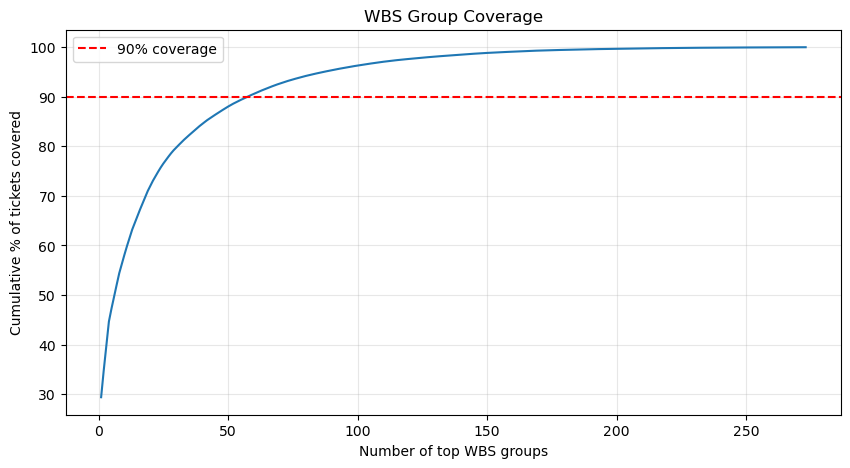

In [56]:
print("Number of unique WBS values:", df["WBS"].nunique())

wbs_counts = df["WBS"].value_counts()
print("\nTop 10 WBS groups cover:", wbs_counts.head(10).sum(), "of", len(df), 
      f"({wbs_counts.head(10).sum()/len(df)*100:.1f}%)")

cumulative_pct = (wbs_counts.cumsum() / len(df) * 100)



plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumulative_pct)+1), cumulative_pct.values)
plt.axhline(90, color="red", linestyle="--", label="90% coverage")
plt.xlabel("Number of top WBS groups")
plt.ylabel("Cumulative % of tickets covered")
plt.title("WBS Group Coverage")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()




In [57]:
n_for_90 = (cumulative_pct < 90).sum() + 1
print(f"Groups needed for 90% coverage: {n_for_90}")
print(f"Coverage at that point: {cumulative_pct.iloc[n_for_90-1]:.2f}%")

for n in [10, 20, 30, 40, n_for_90]:
    print(f"Top {n} groups: {cumulative_pct.iloc[n-1]:.1f}% coverage")

Groups needed for 90% coverage: 58
Coverage at that point: 90.13%
Top 10 groups: 58.2% coverage
Top 20 groups: 72.0% coverage
Top 30 groups: 79.8% coverage
Top 40 groups: 84.5% coverage
Top 58 groups: 90.1% coverage


In [58]:
TOP_N = 30  

top_wbs = wbs_counts.head(TOP_N).index
df["WBS_target"] = df["WBS"].where(df["WBS"].isin(top_wbs), "Other")

print(df["WBS_target"].nunique(), "classes")
print(df["WBS_target"].value_counts().head(TOP_N + 1))

31 classes
WBS_target
WBS000073    13292
Other         9151
WBS000091     2439
WBS000263     2277
WBS000072     2190
WBS000271     1182
WBS000095     1099
WBS000152     1074
WBS000318     1062
WBS000094      859
WBS000146      825
WBS000223      798
WBS000092      749
WBS000128      745
WBS000088      611
WBS000099      608
WBS000228      599
WBS000292      570
WBS000089      566
WBS000296      563
WBS000162      477
WBS000219      461
WBS000096      411
WBS000016      407
WBS000199      387
WBS000187      355
WBS000172      323
WBS000307      318
WBS000125      304
WBS000255      276
WBS000023      248
Name: count, dtype: int64


In [59]:
feature_cols_wbs = ["CI_Cat", "CI_Subcat", "Category", "Impact", "Urgency", "open_hour", "open_dayofweek", "open_month"]

X_wbs = pd.get_dummies(df[feature_cols_wbs], columns=["CI_Cat", "CI_Subcat", "Category"], drop_first=True)
y_wbs = df["WBS_target"]

print(X_wbs.shape)
y_wbs.value_counts(normalize=True).head(5)

(45226, 82)


WBS_target
WBS000073    0.293902
Other        0.202339
WBS000091    0.053929
WBS000263    0.050347
WBS000072    0.048423
Name: proportion, dtype: float64

In [60]:
from sklearn.model_selection import train_test_split

X_train_wbs, X_test_wbs, y_train_wbs, y_test_wbs = train_test_split(
    X_wbs, y_wbs, test_size=0.2, stratify=y_wbs, random_state=42
)
print(X_train_wbs.shape, X_test_wbs.shape)

(36180, 82) (9046, 82)


In [61]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score

rf_wbs = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf_wbs.fit(X_train_wbs, y_train_wbs)

y_pred_wbs = rf_wbs.predict(X_test_wbs)

print("Accuracy:", accuracy_score(y_test_wbs, y_pred_wbs))
print("Macro F1:", f1_score(y_test_wbs, y_pred_wbs, average="macro"))
print("Weighted F1:", f1_score(y_test_wbs, y_pred_wbs, average="weighted"))
print("\n", classification_report(y_test_wbs, y_pred_wbs, zero_division=0))

Accuracy: 0.4478222418748618
Macro F1: 0.41257809674420715
Weighted F1: 0.4814100937150041

               precision    recall  f1-score   support

       Other       0.70      0.31      0.43      1830
   WBS000016       0.18      0.31      0.23        81
   WBS000023       0.14      0.38      0.20        50
   WBS000072       0.49      0.44      0.46       438
   WBS000073       0.79      0.38      0.51      2659
   WBS000088       0.15      0.45      0.22       122
   WBS000089       0.41      0.51      0.46       113
   WBS000091       0.90      0.83      0.87       488
   WBS000092       0.41      0.62      0.49       150
   WBS000094       0.61      0.70      0.65       172
   WBS000095       0.89      0.95      0.92       220
   WBS000096       0.47      0.61      0.53        82
   WBS000099       0.12      0.19      0.15       122
   WBS000125       0.10      0.34      0.15        61
   WBS000128       0.47      0.72      0.57       149
   WBS000146       0.96      0.99      0.9

**Result (clean, creation-time features):** accuracy 0.448, macro F1 **0.413**, weighted F1 0.481. Performance is bimodal. WBS000146, WBS000271, WBS000091, WBS000095 and WBS000292 reach F1 of 0.87-0.99, while WBS000255, WBS000172 and WBS000125 have precision under 0.20. The largest group, WBS000073, has precision 0.79 but recall 0.38.

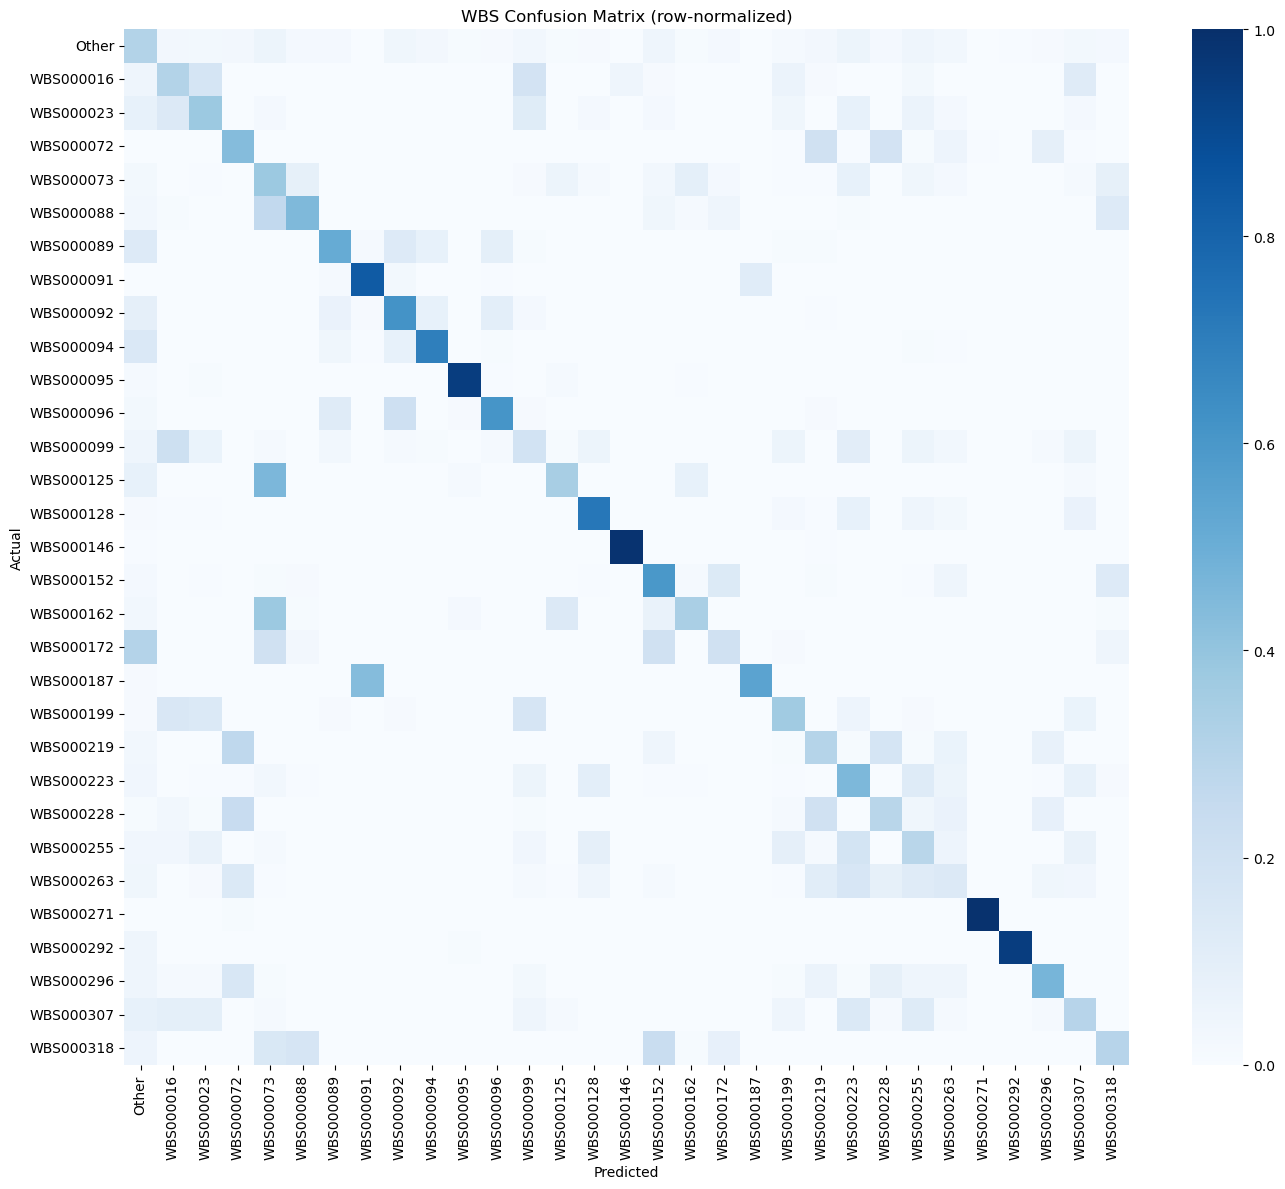

In [62]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

labels = sorted(y_wbs.unique())
cm = confusion_matrix(y_test_wbs, y_pred_wbs, labels=labels)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(14, 12))
sns.heatmap(cm_norm, xticklabels=labels, yticklabels=labels, cmap="Blues", vmin=0, vmax=1)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("WBS Confusion Matrix (row-normalized)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [63]:
weak_groups = ["WBS000255", "WBS000172", "WBS000125", "WBS000219", "WBS000162", "WBS000307"]
for g in weak_groups:
    print(f"\n--- {g} top CI_Cat/CI_Subcat ---")
    print(df[df["WBS"] == g][["CI_Cat", "CI_Subcat"]].value_counts().head(3))


--- WBS000255 top CI_Cat/CI_Subcat ---
CI_Cat       CI_Subcat               
application  Server Based Application    276
Name: count, dtype: int64

--- WBS000172 top CI_Cat/CI_Subcat ---
CI_Cat       CI_Subcat            
application  Web Based Application    320
software     System Software            3
Name: count, dtype: int64

--- WBS000125 top CI_Cat/CI_Subcat ---
CI_Cat             CI_Subcat               
subapplication     Web Based Application       284
                   Server Based Application      9
officeelectronics  Scanner                       6
Name: count, dtype: int64

--- WBS000219 top CI_Cat/CI_Subcat ---
CI_Cat       CI_Subcat               
application  Server Based Application    454
             Desktop Application           7
Name: count, dtype: int64

--- WBS000162 top CI_Cat/CI_Subcat ---
CI_Cat          CI_Subcat               
subapplication  Web Based Application       379
application     Web Based Application        55
subapplication  Server Based App

**Why some groups are weak.** The poorly predicted groups share identical CI signatures. WBS000255, WBS000219 and WBS000307 are all `application / Server Based Application`; WBS000172, WBS000162 and the sub-application group WBS000125 are all Web Based Application variants. From these attributes they are indistinguishable, which caps the achievable accuracy. The real driver may be something not captured, such as sub-team specialisation or the application name.

In [64]:
feature_cols_wbs2 = feature_cols_wbs + ["No_of_Reassignments", "Closure_Code"]
X_wbs2 = pd.get_dummies(df[feature_cols_wbs2], columns=["CI_Cat", "CI_Subcat", "Category", "Closure_Code"], drop_first=True)

X_train_wbs2, X_test_wbs2, y_train_wbs2, y_test_wbs2 = train_test_split(
    X_wbs2, y_wbs, test_size=0.2, stratify=y_wbs, random_state=42
)

rf_wbs2 = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1)
rf_wbs2.fit(X_train_wbs2, y_train_wbs2)
y_pred_wbs2 = rf_wbs2.predict(X_test_wbs2)

print("Macro F1:", f1_score(y_test_wbs2, y_pred_wbs2, average="macro"))
print("Weighted F1:", f1_score(y_test_wbs2, y_pred_wbs2, average="weighted"))


Macro F1: 0.5567047342044017
Weighted F1: 0.6567763497265172


In [65]:
feature_cols_wbs3 = feature_cols_wbs + ["No_of_Reassignments"]
X_wbs3 = pd.get_dummies(df[feature_cols_wbs3], columns=["CI_Cat", "CI_Subcat", "Category"], drop_first=True)

X_train_wbs3, X_test_wbs3, y_train_wbs3, y_test_wbs3 = train_test_split(
    X_wbs3, y_wbs, test_size=0.2, stratify=y_wbs, random_state=42
)

rf_wbs3 = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1)
rf_wbs3.fit(X_train_wbs3, y_train_wbs3)
y_pred_wbs3 = rf_wbs3.predict(X_test_wbs3)

print("Macro F1 (No_of_Reassignments only):", f1_score(y_test_wbs3, y_pred_wbs3, average="macro"))
print("Weighted F1:", f1_score(y_test_wbs3, y_pred_wbs3, average="weighted"))


Macro F1 (No_of_Reassignments only): 0.45899028135697273
Weighted F1: 0.5607674948158986


**Leakage check.**

| Feature set | Macro F1 | Weighted F1 |
|---|---|---|
| Clean baseline (headline model) | 0.413 | 0.481 |
| + `No_of_Reassignments` | 0.459 | 0.561 |
| + `No_of_Reassignments` + `Closure_Code` | 0.557 | 0.657 |

`Closure_Code` and the reassignment count are not known at ticket creation, so the higher scores are leakage. They are shown only to explain why they must not be used, and the clean baseline is the headline result.

### 5.3 Why routing matters: the cost of reassignment

Reassignments are common: the mean is 1.14 per ticket (maximum 46), 58.8% of tickets are never reassigned and 41.2% are reassigned at least once. The buckets below compare elapsed resolution time.

In [66]:
df["No_of_Reassignments"] = pd.to_numeric(df["No_of_Reassignments"], errors="coerce").fillna(0)

print("Overall mean reassignments:", round(df["No_of_Reassignments"].mean(), 2))
print(df["No_of_Reassignments"].describe())

df["reassign_bucket"] = pd.cut(df["No_of_Reassignments"], [-1, 0, 1, 3, 10, 1e6],
                               labels=["0", "1", "2-3", "4-10", "10+"])
print(df.groupby("reassign_bucket", observed=True)["Handle_Time_hrs"]
        .agg(["count", "median", "mean"]))

Overall mean reassignments: 1.14
count    45226.000000
mean         1.141025
std          2.284451
min          0.000000
25%          0.000000
50%          0.000000
75%          2.000000
max         46.000000
Name: No_of_Reassignments, dtype: float64
                 count      median         mean
reassign_bucket                                
0                26595    2.550000    39.743586
1                 7036   24.950000   115.354873
2-3               7368   74.800000   212.417393
4-10              3772  187.883333   436.482295
10+                455  619.016667  1164.310513


In [67]:
tot = df.groupby("reassign_bucket", observed=True)["Handle_Time_hrs"].sum()
print("Share of total elapsed time by bucket:\n", (tot / tot.sum()).round(3))

act_r = df[df["Open_Time"] >= "2013-09-24"]
print("\nActive period only:")
print(act_r.groupby("reassign_bucket", observed=True)["Handle_Time_hrs"]
        .agg(["count", "median"]))

print("\nReassignments by assignment group (top 30 groups):")
print(df[df["WBS_target"] != "Other"]
        .groupby("WBS_target")["No_of_Reassignments"].agg(["mean", "count"])
        .sort_values("mean", ascending=False).head(10))


Share of total elapsed time by bucket:
 reassign_bucket
0       0.188
1       0.145
2-3     0.279
4-10    0.293
10+     0.094
Name: Handle_Time_hrs, dtype: float64

Active period only:
                 count      median
reassign_bucket                   
0                26539    2.550000
1                 6980   24.733333
2-3               7208   72.875000
4-10              3552  169.958333
10+                378  502.475000

Reassignments by assignment group (top 30 groups):
                mean  count
WBS_target                 
WBS000088   3.602291    611
WBS000162   3.582809    477
WBS000271   3.140440   1182
WBS000263   2.801054   2277
WBS000072   1.971233   2190
WBS000296   1.387211    563
WBS000187   1.366197    355
WBS000091   1.340713   2439
WBS000152   1.282123   1074
WBS000318   1.161959   1062


**Findings.** Median elapsed resolution time rises steeply with each reassignment: 2.6 hours with none, 25 hours with one, 75 with 2-3, 188 with 4-10 and 619 hours (about 26 days) with more than 10. Tickets with four or more reassignments are 9.3% of tickets but about **39%** of total elapsed time (29.3% + 9.4%). The pattern is the same when only the active period is used, so the old backlog is not driving it.

This is an association, not proof of cause: difficult tickets both bounce more and take longer.

In [68]:
from sklearn.metrics import f1_score

labels = sorted(y_wbs.unique())
f1 = pd.Series(f1_score(y_test_wbs, y_pred_wbs, average=None, labels=labels),
               index=labels, name="model_f1")
grp = (df[df["WBS_target"] != "Other"]
       .groupby("WBS_target")["No_of_Reassignments"]
       .agg(mean_reassign="mean", tickets="count"))
tab = grp.join(f1)
tab["total_reassignments"] = tab["mean_reassign"] * tab["tickets"]
print(tab.sort_values("total_reassignments", ascending=False).head(10).round(2))

            mean_reassign  tickets  model_f1  total_reassignments
WBS_target                                                       
WBS000073            0.77    13292      0.51              10181.0
WBS000263            2.80     2277      0.18               6378.0
WBS000072            1.97     2190      0.46               4317.0
WBS000271            3.14     1182      0.99               3712.0
WBS000091            1.34     2439      0.87               3270.0
WBS000088            3.60      611      0.22               2201.0
WBS000162            3.58      477      0.15               1709.0
WBS000152            1.28     1074      0.42               1377.0
WBS000318            1.16     1062      0.21               1234.0
WBS000296            1.39      563      0.39                781.0


**Where the reassignments happen** (about 51,600 in total; the top ten groups absorb roughly 68% of them):

- **Auto-route now:** WBS000271 (F1 0.99) and WBS000091 (F1 0.87) are routed accurately by the model yet absorb about 13.5% of all reassignments. Routing them correctly at ticket creation could remove up to that many handoffs.
- **Needs better data:** WBS000263, WBS000088, WBS000162 and WBS000318 combine heavy reassignment with poor model performance (F1 0.15-0.22) and about 22% of all reassignments. Capturing an application name or sub-team tag at creation is the likely fix.
- **Largest by volume:** WBS000073 has a low average (0.77) but 13,292 tickets, so small routing gains matter.

Some handoffs may be intentional escalations (for example into a second-line group), so savings should be quoted as an upper bound and checked with the client.

## 6. Sub-task 4: Change (RFC) and asset risk

**Goal (brief item 4):** predict changes and the possible failure or misconfiguration of ITSM assets.

**What the data does and does not contain.** There is **no change table and no change-outcome field**, so "RFC failure" cannot be labeled directly. Changes are visible only through `Related_Change` on incidents. The analysis therefore uses change-linked incidents as a proxy for problematic changes, plus a ranking of assets (configuration items) from their incident history.

### 6.1 Change-linked incidents and RFC risk

In [69]:
print(df[["Related_Change", "No_of_Related_Changes"]].describe(include="all"))
print("\nNon-null Related_Change sample values:")
print(df[df["Related_Change"].notna() & (df["Related_Change"] != "None")]["Related_Change"].head(10))

       Related_Change  No_of_Related_Changes
count           45226                  45226
unique            221                      5
top              None                      0
freq            44701                  44701

Non-null Related_Change sample values:
10       C00000056
38     #MULTIVALUE
43       C00000308
54       C00000582
119      C00006478
133      C00000778
134    #MULTIVALUE
136      C00006478
139      C00002486
159      C00000577
Name: Related_Change, dtype: object


In [70]:
df["No_of_Related_Changes"] = pd.to_numeric(df["No_of_Related_Changes"], errors="coerce").fillna(0)
df["has_related_change"] = (df["Related_Change"] != "None").astype(int)

print(df["has_related_change"].value_counts())
print(df["No_of_Related_Changes"].value_counts().head())

for col in ["CI_Cat", "CI_Subcat", "Category", "Closure_Code"]:
    print(f"\n--- {col} ---")
    print(df.groupby(col)["has_related_change"].agg(["mean", "sum", "count"])
            .sort_values("sum", ascending=False).head(10))

print(df[df["has_related_change"] == 1]["Open_Time"].dt.to_period("M").value_counts().sort_index())


has_related_change
0    44701
1      525
Name: count, dtype: int64
No_of_Related_Changes
0    44701
1      502
2       20
3        2
9        1
Name: count, dtype: int64

--- CI_Cat ---
                          mean  sum  count
CI_Cat                                    
application           0.012015  383  31877
subapplication        0.012953  100   7720
computer              0.005643   20   3544
software              0.054422   16    294
Unknown               0.027778    3    108
networkcomponents     0.010101    1     99
hardware              0.002463    1    406
database              0.005952    1    168
Phone                 0.000000    0      2
applicationcomponent  0.000000    0      4

--- CI_Subcat ---
                              mean  sum  count
CI_Subcat                                     
Web Based Application     0.014962  227  15172
Server Based Application  0.009687  175  18065
Desktop Application       0.013481   50   3709
Citrix                    0.035433   27    7

**Change-linked incidents.** 525 of 45,226 tickets (1.16%) are linked to a change, and 70% of those (366) have `Closure_Code = Software`. They cluster from October 2013 in bursts (170 in November 2013, 108 in February 2014). Prevalence is near the base rate for the large CI categories and higher for small groups such as software (5.4%), System Software (5.6%) and Windows Server (4.3%); those groups are small, so this is indicative only.

In [71]:
chg = df[df["has_related_change"] == 1].copy()
chg["change_id"] = chg["Related_Change"].astype(str).str.split(r"[,;\s]+")
chg = chg.explode("change_id")
chg = chg[chg["change_id"].str.len() > 0]

rfc = chg.groupby("change_id").agg(
    n_incidents=("Incident_ID", "nunique"),
    n_cis=("CI_Name", "nunique"),
    first_incident=("Open_Time", "min"),
    last_incident=("Open_Time", "max"),
    high_priority=("is_high_priority", "sum"),
    reopened=("Reopen_Time_missing", lambda s: (s == 0).sum()),
    median_handle_hrs=("Handle_Time_hrs", "median"),
    software_share=("Closure_Code", lambda s: (s == "Software").mean()),
).reset_index()

print(len(rfc))
print(rfc["n_incidents"].value_counts().sort_index().head(15))

print(rfc.sort_values("n_incidents", ascending=False).head(10))


220
n_incidents
1      172
2       25
3       10
4        1
5        3
7        2
9        1
10       2
15       1
23       1
63       1
110      1
Name: count, dtype: int64
       change_id  n_incidents  n_cis      first_incident       last_incident  \
51     C00003013          110      6 2013-11-04 11:03:00 2013-11-08 09:32:00   
186    C00014762           63      3 2014-02-17 08:42:00 2014-02-27 12:11:00   
0    #MULTIVALUE           23     15 2013-03-05 13:58:00 2014-03-10 16:17:00   
98     C00007098           15      4 2013-12-02 09:55:00 2013-12-02 15:10:00   
22     C00001012           10      1 2013-11-14 12:06:00 2013-11-18 13:38:00   
158    C00012714           10      1 2014-01-30 15:20:00 2014-01-30 15:53:00   
17     C00000713            9      3 2013-10-11 08:59:00 2013-10-11 10:10:00   
120    C00009165            7      1 2013-12-12 10:00:00 2013-12-12 15:31:00   
129    C00009722            7      1 2013-11-19 16:28:00 2013-12-18 10:05:00   
116    C00008750          

**RFC-level view.** `Related_Change` is expanded to one row per change: 220 distinct values, including `#MULTIVALUE`, a placeholder for tickets linked to more than one change (23 tickets, matching the 20 + 2 + 1 tickets with two, three or nine related changes). The real IDs for those are lost, so the placeholder is excluded, leaving **219 changes**. 172 (78%) have a single linked incident, and the two largest, C00003013 (110 incidents, 4-8 Nov 2013) and C00014762 (63 incidents, 17-27 Feb 2014), hold 34.5% of all change-linked incidents.

In [72]:
rfc_real = rfc[rfc["change_id"] != "#MULTIVALUE"].copy()

rfc_real["breadth_tier"] = pd.cut(
    rfc_real["n_incidents"], bins=[0, 1, 4, 1000],
    labels=["single", "small (2-4)", "wide (5+)"]
)
rfc_real["severity_flag"] = (
    (rfc_real["high_priority"] > 0) | (rfc_real["reopened"] > 0)
).astype(int)

print(pd.crosstab(rfc_real["breadth_tier"], rfc_real["severity_flag"], margins=True))

s = rfc_real.sort_values("n_incidents", ascending=False)
s["cum_share"] = s["n_incidents"].cumsum() / s["n_incidents"].sum()
print(s[["change_id", "n_incidents", "cum_share"]].head(10))


sev_ids = rfc_real.loc[rfc_real["severity_flag"] == 1, "change_id"]
sev = chg[chg["change_id"].isin(sev_ids)]
print(sev.groupby(["CI_Cat", "CI_Subcat"]).size().sort_values(ascending=False).head(10))

severity_flag    0   1  All
breadth_tier               
single         145  27  172
small (2-4)     30   6   36
wide (5+)        6   5   11
All            181  38  219
     change_id  n_incidents  cum_share
51   C00003013          110   0.219124
186  C00014762           63   0.344622
98   C00007098           15   0.374502
22   C00001012           10   0.394422
158  C00012714           10   0.414343
17   C00000713            9   0.432271
120  C00009165            7   0.446215
129  C00009722            7   0.460159
116  C00008750            5   0.470120
176  C00014221            5   0.480080
CI_Cat          CI_Subcat               
application     Server Based Application    22
                Web Based Application       19
subapplication  Web Based Application       18
computer        Omgeving                     4
Unknown         Unknown                      3
application     Citrix                       2
computer        Laptop                       2
application     Desktop Applicati

In [73]:
df["reopened"] = (df["Reopen_Time_missing"] == 0).astype(int)

print(df.groupby("has_related_change")[["is_high_priority", "reopened"]].mean().round(4))
print(df.groupby("has_related_change")["Handle_Time_hrs"].median())

from scipy.stats import chi2_contingency
for c in ["is_high_priority", "reopened"]:
    p = chi2_contingency(pd.crosstab(df["has_related_change"], df[c]))[1]
    print(c, "p =", round(p, 4))

                    is_high_priority  reopened
has_related_change                            
0                             0.0150    0.0497
1                             0.0571    0.0324
has_related_change
0    18.783333
1    16.683333
Name: Handle_Time_hrs, dtype: float64
is_high_priority p = 0.0
reopened p = 0.0857


**Are change-linked tickets more serious?** The high-priority rate is 5.71% for change-linked tickets against 1.50% for the rest (about 3.8 times higher, chi-square p < 0.0001). The reopen rate is not higher (3.24% vs 4.97%, p = 0.086) and median elapsed time is similar (16.7 vs 18.8 hours). Because priority comes from the Impact x Urgency matrix, this shows that change-linked incidents are assigned higher business impact, not that changes cause worse incidents.

In [74]:
rfc_real["risk_tier"] = np.select(
    [(rfc_real["n_incidents"] >= 5) & (rfc_real["severity_flag"] == 1),
     (rfc_real["n_incidents"] >= 5) & (rfc_real["severity_flag"] == 0),
     (rfc_real["n_incidents"] < 5) & (rfc_real["severity_flag"] == 1)],
    ["Wide + severe (watchlist)", "Wide, mild (mass event)", "Narrow, severe"],
    default="Low risk"
)
print(rfc_real["risk_tier"].value_counts())

watch = rfc_real[rfc_real["risk_tier"] == "Wide + severe (watchlist)"]
print(watch.sort_values("n_incidents", ascending=False))

rfc_real.to_csv("rfc_risk_summary.csv", index=False)

risk_tier
Low risk                     175
Narrow, severe                33
Wide, mild (mass event)        6
Wide + severe (watchlist)      5
Name: count, dtype: int64
     change_id  n_incidents  n_cis      first_incident       last_incident  \
17   C00000713            9      3 2013-10-11 08:59:00 2013-10-11 10:10:00   
120  C00009165            7      1 2013-12-12 10:00:00 2013-12-12 15:31:00   
129  C00009722            7      1 2013-11-19 16:28:00 2013-12-18 10:05:00   
176  C00014221            5      2 2014-02-12 07:58:00 2014-02-12 08:02:00   
210  C00017302            5      1 2014-03-21 08:21:00 2014-03-21 08:34:00   

     high_priority  reopened  median_handle_hrs  software_share breadth_tier  \
17               1         0           1.216667        0.000000    wide (5+)   
120              1         0          10.250000        0.857143    wide (5+)   
129              0         2         598.866667        0.000000    wide (5+)   
176              1         0           1.30

**Risk tiers.** Each change is classified by breadth (number of linked incidents) and severity (any linked P1/P2 or reopened incident):

| Tier | Definition | Changes |
|---|---|---|
| Low risk | Fewer than 5 incidents, no severity flag | 175 |
| Narrow, severe | Fewer than 5 incidents, at least one P1/P2 or reopen | 33 |
| Wide, mild (mass event) | 5+ incidents, no severity flag | 6 |
| **Wide + severe (watchlist)** | 5+ incidents and a severity flag | **5** |

The two largest changes are *mass events*, not severe ones: many quick, low-priority tickets, resolved in hours. The watchlist is the more useful list. Four of its five changes are short bursts (C00000713, C00009165, C00014221, C00017302) resolved within hours, while **C00009722** is a chronic problem on a single CI with two reopens and a median of about 599 hours.

In [75]:
def max_in_window(times, minutes=60):
    t = times.sort_values().values
    best = 0
    for i in range(len(t)):
        j = np.searchsorted(t, t[i] + np.timedelta64(minutes, "m"), side="right")
        best = max(best, j - i)
    return best

burst = (chg[chg["change_id"] != "#MULTIVALUE"]
         .groupby("change_id")["Open_Time"].apply(max_in_window)
         .rename("max_incidents_60min").reset_index())

rfc_real = rfc_real.merge(burst, on="change_id", how="left")
print(pd.crosstab(rfc_real["max_incidents_60min"].clip(upper=5), rfc_real["risk_tier"]))

risk_tier            Low risk  Narrow, severe  Wide + severe (watchlist)  \
max_incidents_60min                                                        
1                         164              30                          1   
2                           9               2                          0   
3                           2               1                          1   
5                           0               0                          3   

risk_tier            Wide, mild (mass event)  
max_incidents_60min                           
1                                          0  
2                                          1  
3                                          0  
5                                          5  


**Burst-based alert rule.** The maximum number of incidents linked to one change within any 60-minute window separates the tiers. Eight changes have 5 or more incidents in an hour: 3 watchlist changes and 5 mass events, and no low-risk or narrow-severe change. A threshold of 5+ per hour therefore flags 8 changes, while 3+ flags 12 and catches 4 of the 5 watchlist changes. The rule finds wide changes but not severity (30 of 33 narrow-severe changes have a single incident in their busiest hour, and the chronic change C00009722 has at most one), so review any change with a linked P1/P2 or reopened incident separately. The thresholds were chosen after seeing the same 219 changes, so this is a descriptive recommendation and not a validated detector.

### 6.2 Asset (configuration item) risk ranking

Assets are ranked from their incident history. The first view ranks CIs with at least 30 incidents by P1/P2 rate; the second ranks by absolute P1/P2 count, which also catches small CIs the 30-incident filter hides.

In [76]:
df["No_of_Reassignments"] = pd.to_numeric(df["No_of_Reassignments"], errors="coerce").fillna(0)

ci = df.groupby("CI_Name").agg(
    incidents=("Incident_ID", "count"),
    p1p2=("is_high_priority", "sum"),
    change_linked=("has_related_change", "sum"),
    reopened=("reopened", "sum"),
    mean_reassign=("No_of_Reassignments", "mean"),
    software_share=("Closure_Code", lambda s: (s == "Software").mean()),
).reset_index()
ci["p1p2_rate"] = ci["p1p2"] / ci["incidents"]

ranked = ci[ci["incidents"] >= 30].sort_values("p1p2_rate", ascending=False)
print(len(ci), "CIs;", len(ranked), "with 30+ incidents")
print(ranked.head(15))
ranked.to_csv("ci_risk_ranking.csv", index=False)

2928 CIs; 175 with 30+ incidents
        CI_Name  incidents  p1p2  change_linked  reopened  mean_reassign  \
2499  SBA000773         31    14              0         2       0.548387   
2776  WBA000107         55     7              4         5       3.036364   
962   DTA000027         74     6              0         4       0.486486   
2225  SBA000025         44     3              1         1       0.477273   
2101  OVR000033         50     3              3         3       0.940000   
2206  SAN000178         70     4              0         0       0.914286   
2670  SUB000508        303    16             15        19       4.155116   
11    APP000004        104     5              2         1       0.894231   
2278  SBA000154        133     6              0        12       1.248120   
2259  SBA000101         98     4              0         8       2.724490   
2273  SBA000142         51     2              0         1       0.921569   
2226  SBA000026         86     3              0        

In [77]:
top_cnt = ci.sort_values("p1p2", ascending=False).copy()
top_cnt["cum_share"] = top_cnt["p1p2"].cumsum() / top_cnt["p1p2"].sum()
print(top_cnt.head(15)[["CI_Name", "incidents", "p1p2", "p1p2_rate", "cum_share"]])
print((ci["p1p2"] > 0).sum(), "of", len(ci), "CIs have at least one P1/P2")
print("Overall mean reassignments:", round(df["No_of_Reassignments"].mean(), 2))

        CI_Name  incidents  p1p2  p1p2_rate  cum_share
2786  WBA000124        607    21   0.034596   0.030000
2670  SUB000508        303    16   0.052805   0.052857
2499  SBA000773         31    14   0.451613   0.072857
960   DTA000025        324    11   0.033951   0.088571
2616  SUB000113       1097    10   0.009116   0.102857
2776  WBA000107         55     7   0.127273   0.112857
210   CBD000493          6     6   1.000000   0.121429
962   DTA000027         74     6   0.081081   0.130000
2278  SBA000154        133     6   0.045113   0.138571
2366  SBA000405         11     6   0.545455   0.147143
12    APP000005        467     5   0.010707   0.154286
11    APP000004        104     5   0.048077   0.161429
2426  SBA000604         23     5   0.217391   0.168571
2792  WBA000133       1448     5   0.003453   0.175714
150   CBD000415          4     4   1.000000   0.181429
429 of 2928 CIs have at least one P1/P2
Overall mean reassignments: 1.14


**Findings.** 2,928 CIs appear in the data, 175 have 30+ incidents and only 429 (14.7%) have ever had a P1/P2 ticket. The base P1/P2 rate is 1.55% and the mean reassignment count is 1.14.

- **P1/P2 tickets are spread thinly.** The top 10 CIs by count hold 14.7% of all P1/P2 tickets and the top 15 hold 18.1%, so an asset-only strategy can cover only a minority.
- **Volume is not criticality.** SUB000113 (1,097 tickets, 0.9% P1/P2) and WBA000133 (1,448 tickets, 0.35%) are below the base rate.
- **Small but almost always critical:** CBD000493 (6 of 6), CBD000415 (4 of 4), SBA000405 (6 of 11) and SBA000604 (5 of 23). Small counts can be chance, so treat them as candidates for review.
- **Standout by rate:** SBA000773 has 14 of its 31 tickets at P1/P2 (45%), about 30 times the base rate.
- **Troublesome on several measures:** WBA000107, SUB000508 and WBA000124 combine high P1/P2 counts, many change-linked or reopened tickets and mean reassignments above 3 (3.04, 4.16 and 3.60).

This ranking is descriptive (whole-period history), not a prediction.

### 6.3 Can ticket attributes predict change-linked incidents?

A logistic regression predicts `has_related_change` from creation-time attributes, with a time-ordered 80/20 split. `open_month` is left out on purpose, because the change-linked tickets come in bursts and the model would just memorize busy months. The result is judged by PR-AUC against the test prevalence, which is what a random guess would score.

In [78]:

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, classification_report

d = df.sort_values("Open_Time")
cat_cols = ["CI_Cat", "CI_Subcat", "Category", "Impact", "Urgency"]
X_chg = pd.get_dummies(d[cat_cols + ["open_hour", "open_dayofweek"]],
                       columns=cat_cols, drop_first=True)
y_chg = d["has_related_change"]

cut = int(len(d) * 0.8)                       
Xc_tr, Xc_te = X_chg.iloc[:cut], X_chg.iloc[cut:]
yc_tr, yc_te = y_chg.iloc[:cut], y_chg.iloc[cut:]

clf_chg = LogisticRegression(class_weight="balanced", max_iter=2000).fit(Xc_tr, yc_tr)
proba_chg = clf_chg.predict_proba(Xc_te)[:, 1]

print("Test prevalence (random-guess PR-AUC):", round(yc_te.mean(), 4))
print("PR-AUC:", round(average_precision_score(yc_te, proba_chg), 4))
print(classification_report(yc_te, (proba_chg > 0.5).astype(int), zero_division=0))

Test prevalence (random-guess PR-AUC): 0.0112
PR-AUC: 0.0191
              precision    recall  f1-score   support

           0       0.98      0.46      0.62      8945
           1       0.01      0.38      0.02       101

    accuracy                           0.46      9046
   macro avg       0.50      0.42      0.32      9046
weighted avg       0.97      0.46      0.62      9046

